In [19]:
1+1

2

In [20]:
# %pip install numpy pandas torch 
%pip install matplotlib seaborn 

Note: you may need to restart the kernel to use updated packages.


In [21]:
import numpy as np
import matplotlib.pyplot as plt

In [22]:
n = 100 
rng = np.random.default_rng()
X = 2 * rng.random((n,1)) # Eingabe 
y = 4  + 3*X + rng.normal(0,1, (n,1))

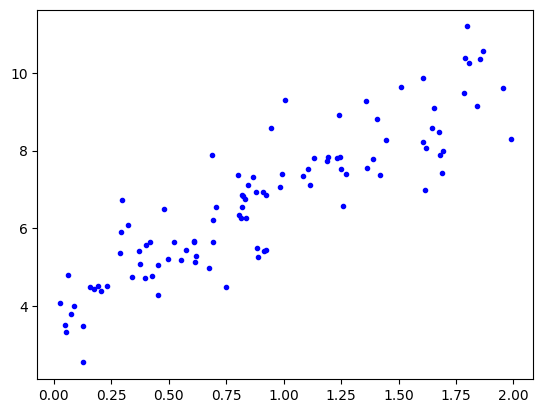

In [23]:
plt.figure()
plt.plot(X,y, "b.")
plt.show()

In [24]:
X_b = np.hstack([X, np.ones((n,1))]) # feature engineering 
X_b

array([[0.37182441, 1.        ],
       [1.19426972, 1.        ],
       [1.44345186, 1.        ],
       [0.91677022, 1.        ],
       [1.79785815, 1.        ],
       [1.23965372, 1.        ],
       [1.51055857, 1.        ],
       [1.85381662, 1.        ],
       [1.65638686, 1.        ],
       [0.02686082, 1.        ],
       [1.61746971, 1.        ],
       [0.32421007, 1.        ],
       [0.98474451, 1.        ],
       [1.13287308, 1.        ],
       [0.45534454, 1.        ],
       [1.24596266, 1.        ],
       [0.49850246, 1.        ],
       [1.64598064, 1.        ],
       [1.6941224 , 1.        ],
       [0.67472188, 1.        ],
       [0.86678922, 1.        ],
       [0.15614443, 1.        ],
       [0.2077074 , 1.        ],
       [0.12827463, 1.        ],
       [0.55332031, 1.        ],
       [1.40651378, 1.        ],
       [0.91153783, 1.        ],
       [0.48192883, 1.        ],
       [1.60806985, 1.        ],
       [0.88469459, 1.        ],
       [0.

$$
\mathbf{w} = (\mathbf{X}^T \mathbf{X})^{-1} \mathbf{X}^T \mathbf{y}
$$

In [26]:
# w = rng.random((2,1))
w_best  = np.linalg.inv(X_b.T @ X_b) @ X_b.T @ y
y_pred = X_b @ w # model 
w_best

array([[3.01782918],
       [3.94915909]])

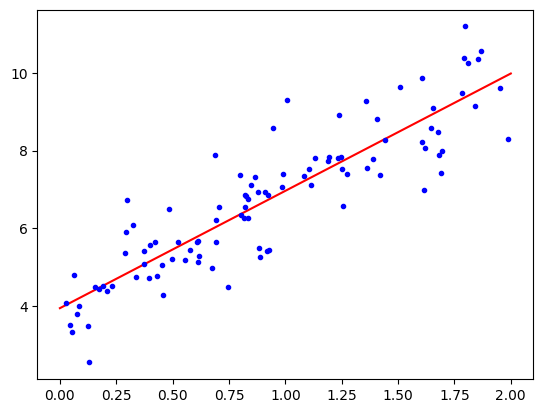

In [27]:
X_new = np.array([[0,1], [2,1]])
# use model equation

y_pred = X_new @ w_best

plt.figure() 
plt.plot(X_new[:,0], y_pred, "r-")
plt.plot(X,y, "b.")
plt.show()


# Batch Gradient Descent

## Loss Funktion 
$$MSE = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2$$


# Gradients
$$\frac{\partial}{\partial m} MSE = -\frac{2}{n} \sum_{i=1}^{n} x_i (y_i - \hat{y}_i)
$$
$$
\frac{\partial}{\partial b} MSE = -\frac{2}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)
$$


# Update
$$
m := m - \eta \cdot \frac{\partial}{\partial m} MSE
$$

$$
b := b - \eta \cdot \frac{\partial}{\partial b} MSE
$$




In [34]:
eta = 0.1 # Lernrate, 0<< eta <1 
epochs = 10 # 1 Mal hat mein ML-Algorithmus den gesamten Datensatz gesehen 

w_bgd = rng.random((2,1))

for epoch in range(epochs): # training loop 
    # gradients 
    gradients = 2 / n * X_b.T @ (X_b @ w_bgd - y )
    # update
    w_bgd = w_bgd - eta*gradients

w_bgd


array([[3.4100241 ],
       [3.49039021]])

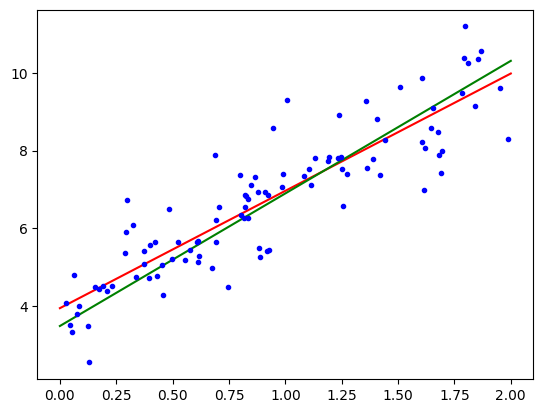

In [35]:
X_new = np.array([[0,1], [2,1]])
# use model equation

y_best = X_new @ w_best
y_bgd = X_new @ w_bgd

plt.figure() 
plt.plot(X_new[:,0], y_pred, "r-")
plt.plot(X_new[:,0], y_bgd, "g-")
plt.plot(X,y, "b.")
plt.show()

# Stochastic Gradient Descent 

In [37]:
eta = 0.01
epochs = 100

w_sgd = rng.random((2,1))

for epoch in range(epochs): # training loop 
    for iter in range(n):
        random_index = rng.integers(0,n)
        xi = X_b[random_index:random_index+1]
        yi = y[random_index:random_index+1] 

        # gradients 
        gradients = 2 * xi.T @ (xi @ w_sgd - yi )
        # update
        w_sgd = w_sgd - eta*gradients

w_sgd


array([[3.00772055],
       [3.9574103 ]])

# Mini-Batch Gradient Descent

In [40]:
eta = 0.01
epochs = 100
B = 10

w_mbgd = rng.random((2,1))

for epoch in range(epochs): # training loop 
    for iter in range(n//B):
        random_index = rng.integers(0,n-B)
        xi = X_b[random_index:random_index+B]
        yi = y[random_index:random_index+B] 

        # gradients 
        gradients = 2 * xi.T @ (xi @ w_mbgd - yi )
        # update
        w_mbgd = w_mbgd - eta*gradients

w_mbgd


array([[2.86899301],
       [3.9908638 ]])

# PyTorch - Einführung

In [43]:
import torch 
x = torch.tensor([1,2,3]) # n-dim Array 
x

tensor([1, 2, 3])

In [45]:
random_tensor = torch.rand(2,3)
random_tensor

tensor([[0.2642, 0.9282, 0.9889],
        [0.1191, 0.7823, 0.5888]])

In [47]:
zeros_tensor = torch.zeros(2,3)
zeros_tensor

tensor([[0., 0., 0.],
        [0., 0., 0.]])

In [48]:
x + random_tensor 

tensor([[1.2642, 2.9282, 3.9889],
        [1.1191, 2.7823, 3.5888]])

In [55]:
a = torch.tensor([[1.,2], [3,4]])
b = torch.tensor([[5.,6], [7,8]])
a @ b


tensor([[19., 22.],
        [43., 50.]])

In [ ]:
device = torch.device("cpu")
device = torch.device("cuda") # NVIDIA GPUs
device = torch.device("mps") # for Apple Silicon 

In [56]:
# Gradients

x = torch.tensor(2.0, requires_grad=True) # Modus: Gradient wird mitgeschleppt 
y = x **2 + 3*x +5 
# 2x + 3 = 2*2 + 3 = 7
y.backward()
x.grad

tensor(7.)

In [ ]:
import torch.nn as nn 
import torch.optim as optim 

# 10 Eingänge, 1 Ausgang -> fully connected feed-forward neural network 
NN = nn.Linear(10, 1) # W*x + b, in Tensorflow - Dense 
# MLP -> Multi-Layer Perceptron 
# Literatur: FC, FC-FFNN, FFN, FNN, MLP 

loss = nn.MSELoss() # mean square error
# loss, cost, criterion, crit 

optimizer = optim.SGD(NN.parameters(), lr=1e-2) 
# lr = Lernrate, eta, alpha
# NN.parameters ... Gewichte und Biases
input_data = torch.rand(10) # X 
output = NN(input_data) # forward, y_pred, predictions, y_hat, Erwartung  
y = torch.ones(1) # ground truth, target, Realität

# Anfangswert der Verlustfunktion 
loss_output = loss(y, output) # Unterschied zwischen Realität und Erwartung 
print(f"Loss: {loss_output:.2} (vor Update)")

# zwei magische Zeilen 
loss_output.backward() # Ableitung der Verlustfunktion bzgl. Parametern 
optimizer.step() # Update von Parameter basierend auf dem ausgewählten Verfahren 


Loss: 0.53 (vor Update)
